In [90]:
#vmax_r240703_ECA.csv

In [1]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr # to read .rds files

In [2]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"


In [6]:

fnames={}

case_id = "FACE_1PFT_AllomBl_r240326_AgBgW_daily"
case_id = "FACE_1PFT_r240701_dL2FR_p0.2" # density 0.2 #/m2

case_ids = ["FACE_1PFT_r240701_dL2FR_p0.2", # density 0.2 #/m2
            "FACE_1PFT_r240701_dL2FR"       # respective densities
           ]
case_ids = ["FACE_1PFT_r240701_dL2FR_p0.2", # density 0.2 #/m2
            "FACE_1PFT_r240704_dL2FR"       # respective densities
           ]

case_ids = ["FACE_1PFT_r240731_dL2FR", # new duke met data
            "FACE_1PFT_r240704_dL2FR"       # respective densities
           ]



sites= ("US-ORN", "US-DUK")
#sites= ("US-ORN",)#, "US-DUK")

#run_case = "spins"
run_case = "trans"
#run_case = "aCO2"
#run_case = "eCO2"

for case_id in case_ids:
    for site in sites:
        # COnly
        fnames[f"{case_id}_{site}_COnly_{run_case}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}.nc"
        # RD
        fn = ['RD','ECA']
        for f in fn:
            fnames[f"{case_id}_{site}_{f}_{run_case}"] = f"{path_in}{case_id}_{f}_processed/{case_id}_{f}_{site}_{run_case}.nc"
        #if site == "US-ORN":
        #    fnames[f"{case_id}_{site}_spins"] = f"{path_in}{case_id}_processed/concatenated_Bharat_H_1PFTallom_r240228_AgBgW_spins_daily_US-ORN_I1850ELMFATES_ad_spinup.nc"
    


In [7]:
 fnames

{'FACE_1PFT_r240731_dL2FR_US-ORN_COnly_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240731_dL2FR_processed/FACE_1PFT_r240731_dL2FR_US-ORN_trans.nc',
 'FACE_1PFT_r240731_dL2FR_US-ORN_RD_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240731_dL2FR_RD_processed/FACE_1PFT_r240731_dL2FR_RD_US-ORN_trans.nc',
 'FACE_1PFT_r240731_dL2FR_US-ORN_ECA_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240731_dL2FR_ECA_processed/FACE_1PFT_r240731_dL2FR_ECA_US-ORN_trans.nc',
 'FACE_1PFT_r240731_dL2FR_US-DUK_COnly_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240731_dL2FR_processed/FACE_1PFT_r240731_dL2FR_US-DUK_trans.nc',
 'FACE_1PFT_r240731_dL2FR_US-DUK_RD_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240731_dL2FR_RD_processed/FACE_1PFT_r240731_dL2FR_RD_US-DUK_trans.nc',
 'FACE_1PFT_r240731_dL2FR_US-DUK_ECA_trans': '/Users/ud4/FATESMDS_analysis/outputs/

In [22]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    print (key)
    ds[key] = xr.open_mfdataset(fnames[key],decode_times=True)
    #ds[key] = xr.open_mfdataset(fnames[key])
    #ds[key] = xr.open_mfdataset(fnames[key], decode_times=False) # inorder to read the "FATES_DAYSINCE_COLDLEAFOFF". because days are interpreted differeny by xarry
    
    
#for idx, key in enumerate(ds.keys()):
#    ds[key]['time'] =  pd.to_datetime(ds[key].time.values.astype(str))

FACE_1PFT_r240731_dL2FR_US-ORN_COnly_trans
FACE_1PFT_r240731_dL2FR_US-ORN_RD_trans
FACE_1PFT_r240731_dL2FR_US-ORN_ECA_trans
FACE_1PFT_r240731_dL2FR_US-DUK_COnly_trans
FACE_1PFT_r240731_dL2FR_US-DUK_RD_trans
FACE_1PFT_r240731_dL2FR_US-DUK_ECA_trans
FACE_1PFT_r240704_dL2FR_US-ORN_COnly_trans
FACE_1PFT_r240704_dL2FR_US-ORN_RD_trans
FACE_1PFT_r240704_dL2FR_US-ORN_ECA_trans
FACE_1PFT_r240704_dL2FR_US-DUK_COnly_trans
FACE_1PFT_r240704_dL2FR_US-DUK_RD_trans
FACE_1PFT_r240704_dL2FR_US-DUK_ECA_trans


In [23]:
# How long do you want the simulation plots?
max_r_years = 400
if run_case == "spins":
    output_freq = "yearly" # spins
    multiply_factor = 1 # 365 for daily output; else 1 for yearly
else:
    output_freq = "daily" # spins
    multiply_factor = 365
    if "CO2" in run_case:
        max_r_years = 12

In [24]:
"-".join(key.split("_")[6:])

'trans'

In [25]:
#sim_case = "COnly"
#sim_case = "RD"
#sim_case = "ECA"
sim_cases = [
            "RD",
            #"ECA",
            #"COnly",
]

In [26]:
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        print (key)

FACE_1PFT_r240731_dL2FR_US-ORN_RD_trans
FACE_1PFT_r240731_dL2FR_US-DUK_RD_trans
FACE_1PFT_r240704_dL2FR_US-ORN_RD_trans
FACE_1PFT_r240704_dL2FR_US-DUK_RD_trans


In [27]:
def tmp_legend_name (key):
    if 'p0.2' in key:
        lname1 = "density0.2"
    else:
        if "ORN" in key:
            lname1 = "density0.36_ORN"
        elif "DUK" in key:
            lname1 = "density0.17_DUK"
    return f"{lname1}_{key.split('_')[-2]}_{key.split('_')[-1]}"
    
markers_list = [".", "<", "o","^",".", "<", "o","^"]
colors_list = ["red", "green", "blue", "yellow","red", "green", "blue", "yellow"] 

# following only to compare logging

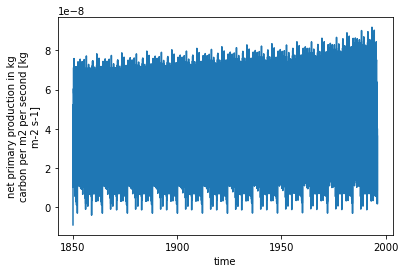

In [30]:
FACE_1PFT_r240704_dL2FR
ds[key][var].plot()

In [39]:
sim_cases

['RD']

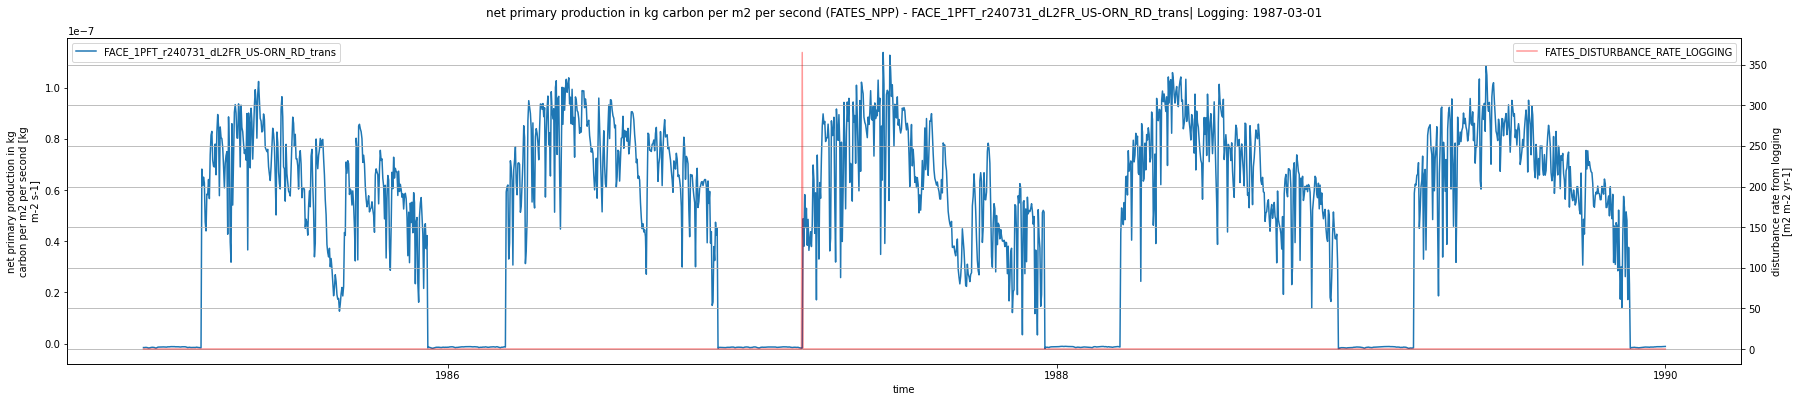

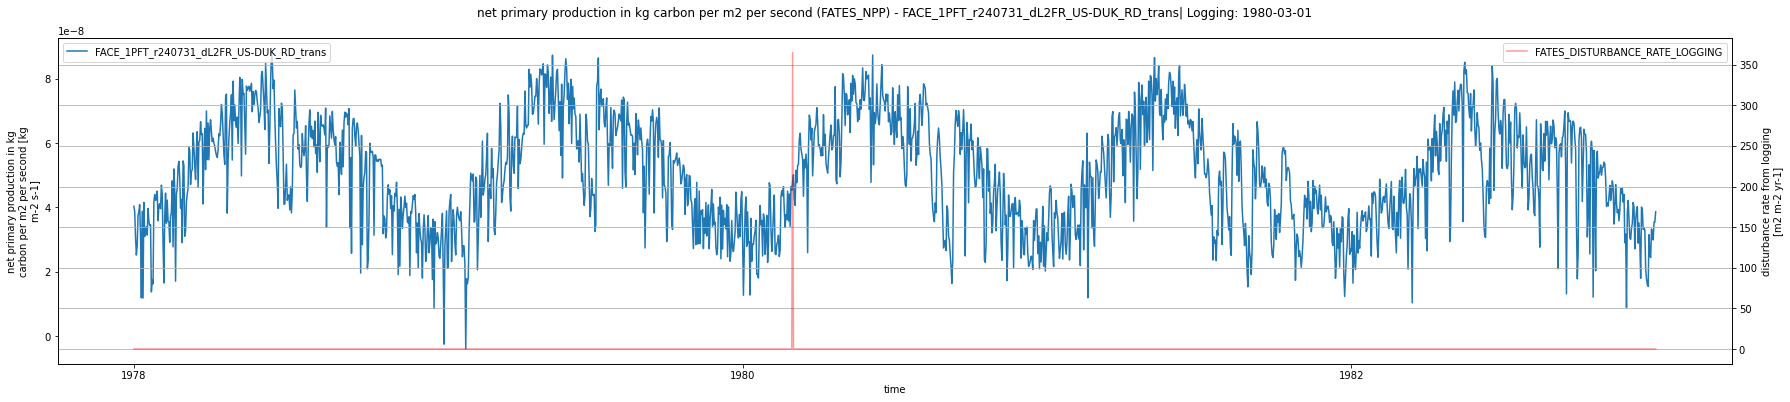

In [113]:
case_id = "FACE_1PFT_r240731_dL2FR"
logging_date_ORN = "1987-03-01"
start_date = "1985-01-01"
end_date = "1990-01-01"

vars = (#"FATES_GPP",
        "FATES_NPP",
        #"FATES_AUTORESP",
        #"FATES_NCOHORTS",
        #"FATES_DISTURBANCE_RATE_LOGGING",
        #"FATES_L2FR",
        #"FATES_LEAFC",
    #"FATES_MORTALITY_CFLUX_CANOPY",
    #"FATES_VEGC",
    #"FATES_MORTALITY_LOGGING_SZ"
       )

plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if ("US-ORN" in key) and (case_id in key):
                ax1 = plt.gca()  # Get current axes
                ds[key][var].sel(time=slice(start_date, end_date)).plot(ax= ax1, label = (key))
                plt.legend(loc='upper left')
                ax2 = ax1.twinx()  
                ds[key]["FATES_DISTURBANCE_RATE_LOGGING"].sel(time=slice(start_date, end_date)).plot(ax= ax2, 
                                                                                                     color='r',
                                                                                                     alpha =0.4,
                                                                                                     label = "FATES_DISTURBANCE_RATE_LOGGING")
                plt.legend(loc='upper right')
                plt.title(f"{ds[key][var].long_name} ({var}) - {key}| Logging: {logging_date_ORN}\n")
                plt.grid()
                
logging_date_DUK = "1980-03-01"
start_date = "1978-01-01"
end_date = "1983-01-01"
# Define the date for the vertical line
vline_date = pd.Timestamp(logging_date_DUK)
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if ("US-DUK" in key) and (case_id in key):
                ax1 = plt.gca()  # Get current axes
                ds[key][var].sel(time=slice(start_date, end_date)).plot(ax= ax1, label = (key))
                plt.legend(loc='upper left')
                ax2 = ax1.twinx()  
                ds[key]["FATES_DISTURBANCE_RATE_LOGGING"].sel(time=slice(start_date, end_date)).plot(ax= ax2, 
                                                                                                     color='r',
                                                                                                     alpha=0.4,
                                                                                                     label = "FATES_DISTURBANCE_RATE_LOGGING")
                plt.legend(loc='upper right')
                plt.title(f"{ds[key][var].long_name} ({var}) - {key}| Logging: {logging_date_DUK}\n")
                plt.grid()
                
                

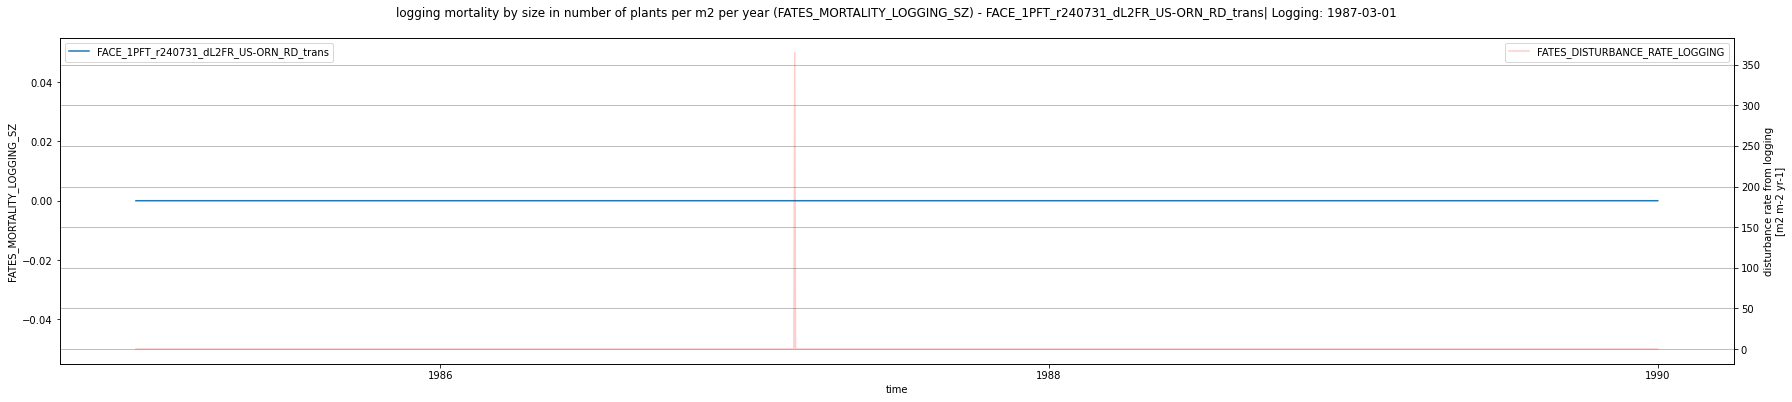

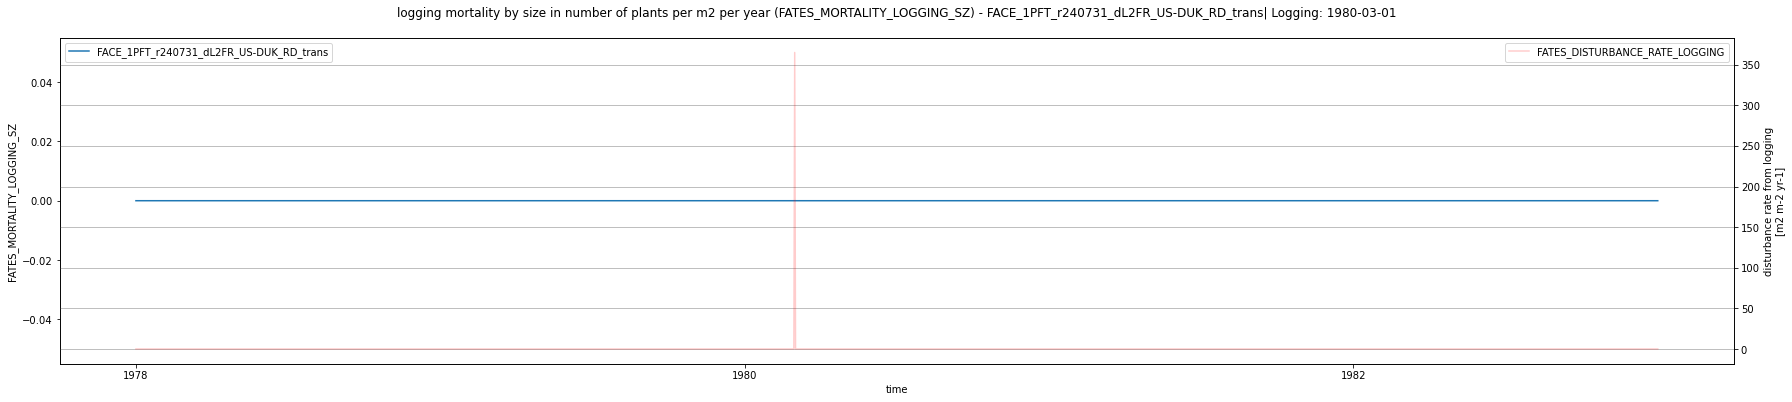

In [100]:
case_id = "FACE_1PFT_r240731_dL2FR"
logging_date_ORN = "1987-03-01"
start_date = "1985-01-01"
end_date = "1990-01-01"

vars = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_AUTORESP",
        #"FATES_NCOHORTS",
        #"FATES_DISTURBANCE_RATE_LOGGING",
        #"FATES_L2FR",
        #"FATES_LEAFC",
    #"FATES_MORTALITY_CFLUX_CANOPY",
    #"FATES_MORTALITY_CFLUX_USTORY",
    "FATES_MORTALITY_LOGGING_SZ",
    #"FATES_MORTALITY_LOGGING_SE_SZ",
    #"FATES_MORTALITY_PF",
       )

plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if ("US-ORN" in key) and (case_id in key):
                ax1 = plt.gca()  # Get current axes
                try:
                    (ds[key][var].sum(dim=["fates_levscls", "lndgrid"])).sel(time=slice(start_date, end_date)).plot(ax= ax1, label = (key))
                except:
                    (ds[key][var].sum(dim=["fates_levpft", "lndgrid"])).sel(time=slice(start_date, end_date)).plot(ax= ax1, label = (key))
                plt.legend(loc='upper left')
                ax2 = ax1.twinx()  
                ds[key]["FATES_DISTURBANCE_RATE_LOGGING"].sel(time=slice(start_date, end_date)).plot(ax= ax2, 
                                                                                                     color='r',
                                                                                                     alpha =0.2,
                                                                                                     label = "FATES_DISTURBANCE_RATE_LOGGING")
                plt.legend(loc='upper right')
                plt.title(f"{ds[key][var].long_name} ({var}) - {key}| Logging: {logging_date_ORN}\n")
                plt.grid()
                
logging_date_DUK = "1980-03-01"
start_date = "1978-01-01"
end_date = "1983-01-01"
# Define the date for the vertical line
vline_date = pd.Timestamp(logging_date_DUK)
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if ("US-DUK" in key) and (case_id in key):
                ax1 = plt.gca()  # Get current axes
                try:
                    (ds[key][var].sum(dim=["fates_levscls", "lndgrid"])).sel(time=slice(start_date, end_date)).plot(ax= ax1, label = (key))
                except:
                    (ds[key][var].sum(dim=["fates_levpft", "lndgrid"])).sel(time=slice(start_date, end_date)).plot(ax= ax1, label = (key))
                plt.legend(loc='upper left')
                ax2 = ax1.twinx()  
                ds[key]["FATES_DISTURBANCE_RATE_LOGGING"].sel(time=slice(start_date, end_date)).plot(ax= ax2, 
                                                                                                     color='r',
                                                                                                     alpha=0.2,
                                                                                                     label = "FATES_DISTURBANCE_RATE_LOGGING")
                plt.legend(loc='upper right')
                plt.title(f"{ds[key][var].long_name} ({var}) - {key}| Logging: {logging_date_DUK}\n")
                plt.grid()
                
                

In [110]:
import pyreadr

result = pyreadr.read_r('/Users/ud4/Documents/FACEMDS/Models/obs_data/OBS_ax.rds') # also works for RData

# done! 
# result is a dictionary where keys are the name of objects and the values python
# objects. In the case of Rds there is only one object with None as key
df = result[None] # extract the pandas data frame 
print(list(df.columns))
df

['YEAR', 'DOY', 'CO2', 'PPT', 'PAR', 'AT', 'ST', 'VPD', 'SW', 'NDEP', 'NEP', 'GPP', 'NPP', 'CEX', 'CVOC', 'RECO', 'RAUTO', 'RLEAF', 'RWOOD', 'RROOT', 'RGROW', 'RHET', 'RSOIL', 'ET', 'T', 'ES', 'EC', 'RO', 'DRAIN', 'LE', 'SH', 'CL', 'CW', 'CCR', 'CFR', 'TNC', 'CFLIT', 'CFLITA', 'CFLITB', 'CCLITB', 'CSOIL', 'GL', 'GW', 'GCR', 'GR', 'GREPR', 'CLLFALL', 'CCRLIN', 'CFRLIN', 'CWIN', 'LAI', 'LMA', 'NCON', 'NCAN', 'NWOOD', 'NCR', 'NFR', 'NSTOR', 'NLIT', 'NRLIT', 'NDW', 'NSOIL', 'NPOOLM', 'NPOOLO', 'NFIX', 'NLITIN', 'NWLIN', 'NCRLIN', 'NFRLIN', 'NUP', 'NGMIN', 'NMIN', 'NVOL', 'NLEACH', 'NGL', 'NGW', 'NGCR', 'NGR', 'APARd', 'GCd', 'GAd', 'GBd', 'Betad', 'NLRETRANS', 'NWRETRANS', 'NCRRETRANS', 'NFRRETRANS', 'LAIpeak', 'NCANpeak', 'CLpeak', 'CFRpeak', 'CCRpeak', 'CWpeak', 'TNCpeak', 'deltaSW', 'deltaCL', 'deltaCW', 'deltaCCR', 'deltaCFR', 'deltaTNC', 'deltaCFLIT', 'deltaCFLITA', 'deltaCFLITB', 'deltaCCLITB', 'deltaCSOIL', 'deltaNCAN', 'deltaNWOOD', 'deltaNCR', 'deltaNFR', 'deltaNSTOR', 'deltaNLIT'

,YEAR,DOY,CO2,PPT,PAR,AT,ST,VPD,SW,NDEP,...,CL_herb,CFR_herb,CFR_lt1mm,CFR_1t2mm,CLLFALL2,SLA,REPRLIN,CLLFALLp,CLLFALLh,LAD
rownames,,,,,,,,,,,,,,,,,,,,,
1,1998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,753.003333
3,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,809.733333
4,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,816.156667
5,2002.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,825.933333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,2009.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
511,2010.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
521,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second


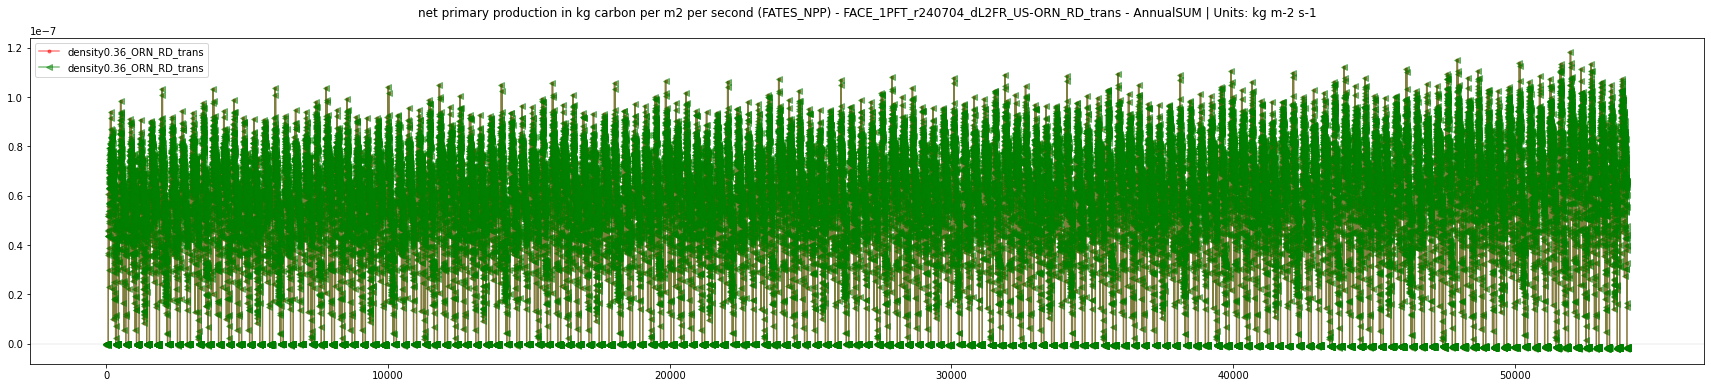

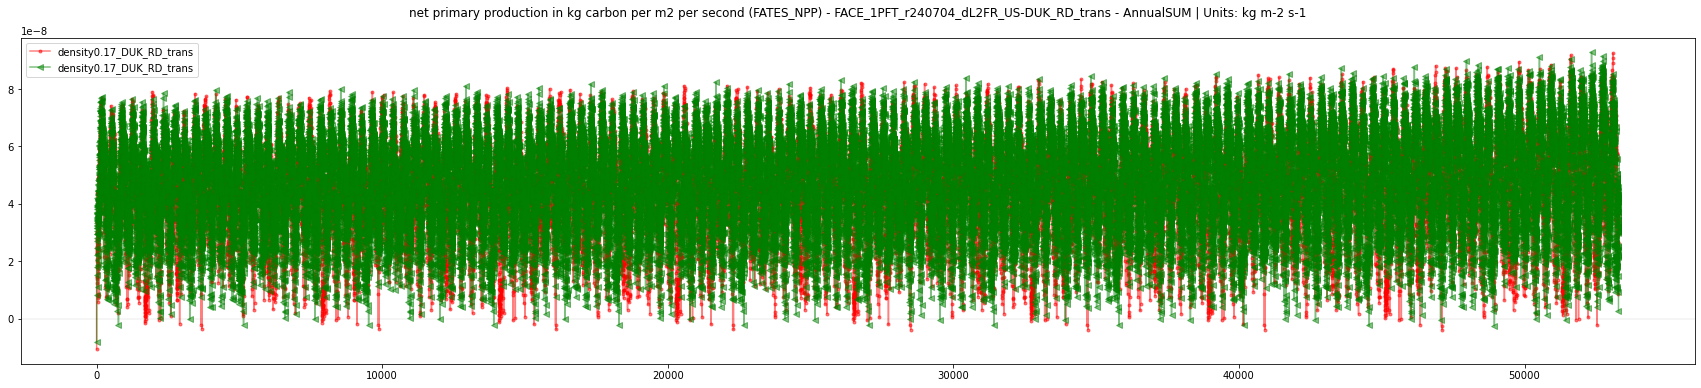

In [28]:
vars = (#"FATES_GPP",
        "FATES_NPP",
        #"FATES_AUTORESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                #if idx != len(ds.keys())-1 : 
                #    plt.xticks([])
                #    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                #plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        #for i in range(max_r_years):
        #    if i%5==0:
        #        plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
        #    if i%10==0:
        #        plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                #if idx != len(ds.keys())-1 : 
                #    plt.xticks([])
                #    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                #plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        #for i in range(max_r_years):
            #if i%5==0:
            #    plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            #if i%10==0:
            #    plt.text(i*multiply_factor,0, int(i))

In [16]:
tmp_legend_name(key)

'density0.17_DUK_ECA_trans'

net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second


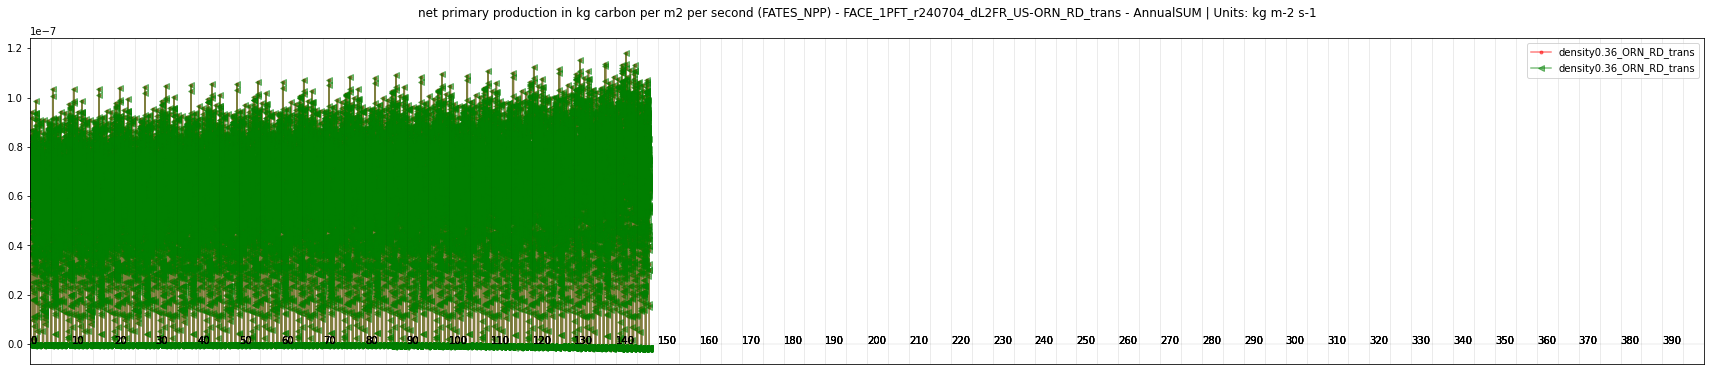

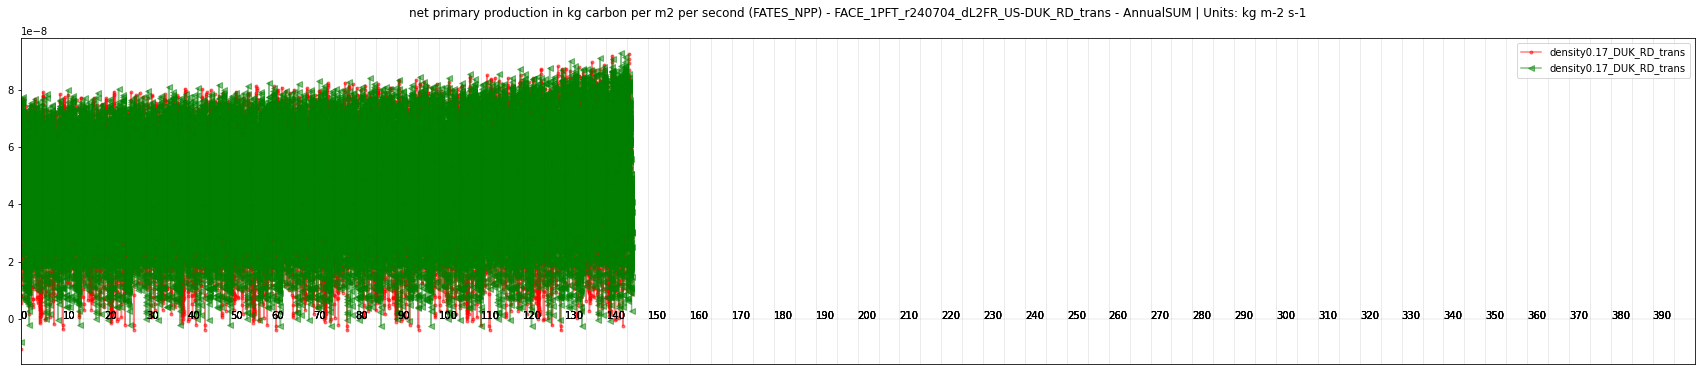

In [17]:
vars = (#"FATES_GPP",
        "FATES_NPP",
        #"FATES_AUTORESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

The leaf to fineroot biomass multiplier for target allometry
The leaf to fineroot biomass multiplier for target allometry
The leaf to fineroot biomass multiplier for target allometry
The leaf to fineroot biomass multiplier for target allometry


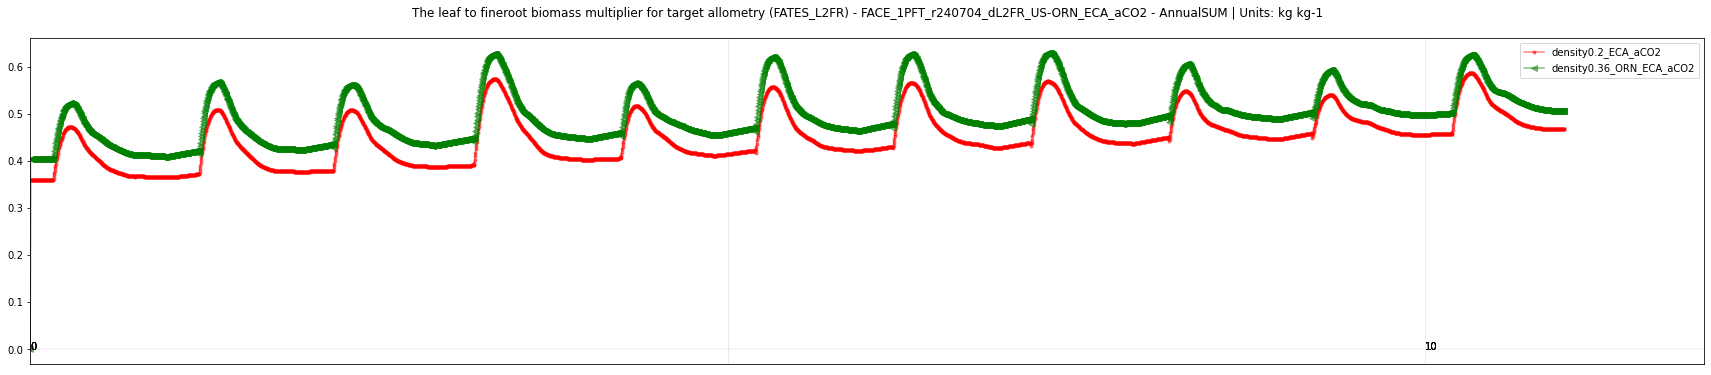

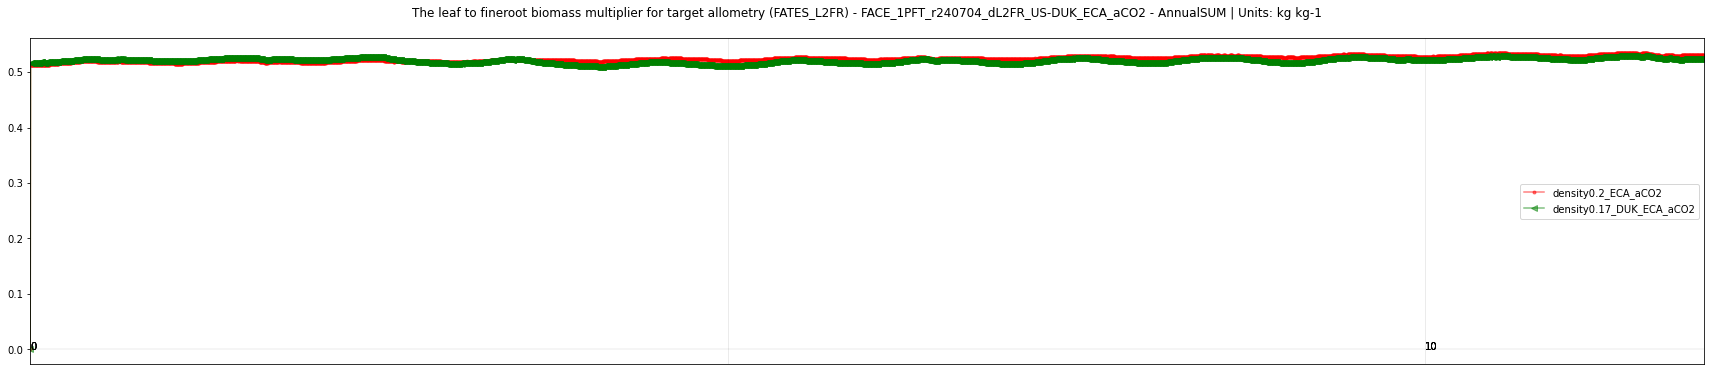

In [103]:
vars = (#"FATES_GPP",
        "FATES_L2FR",
        #"FATES_AUTORESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second


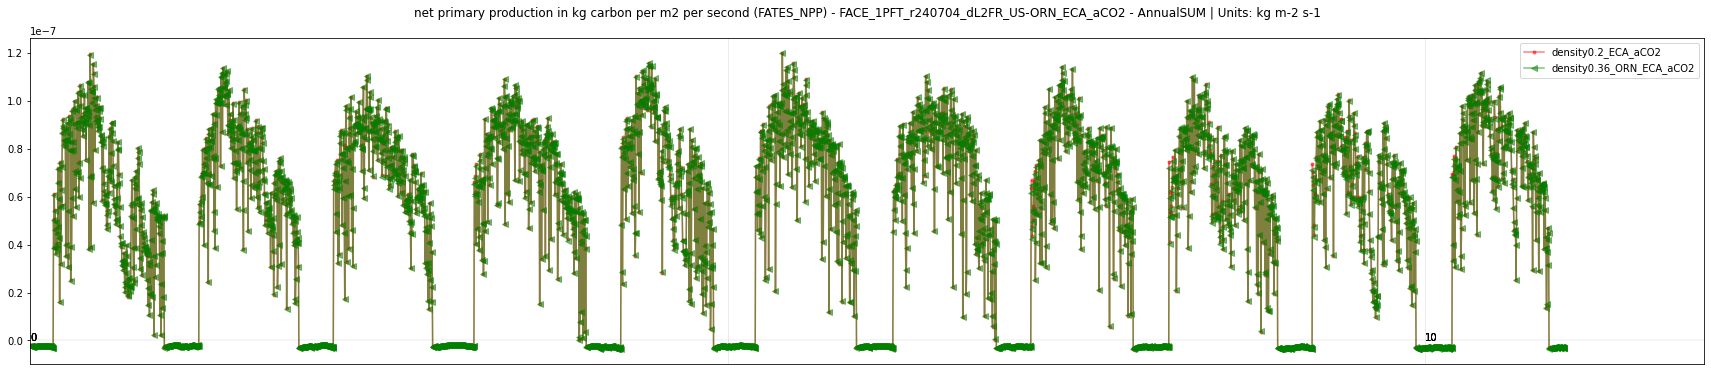

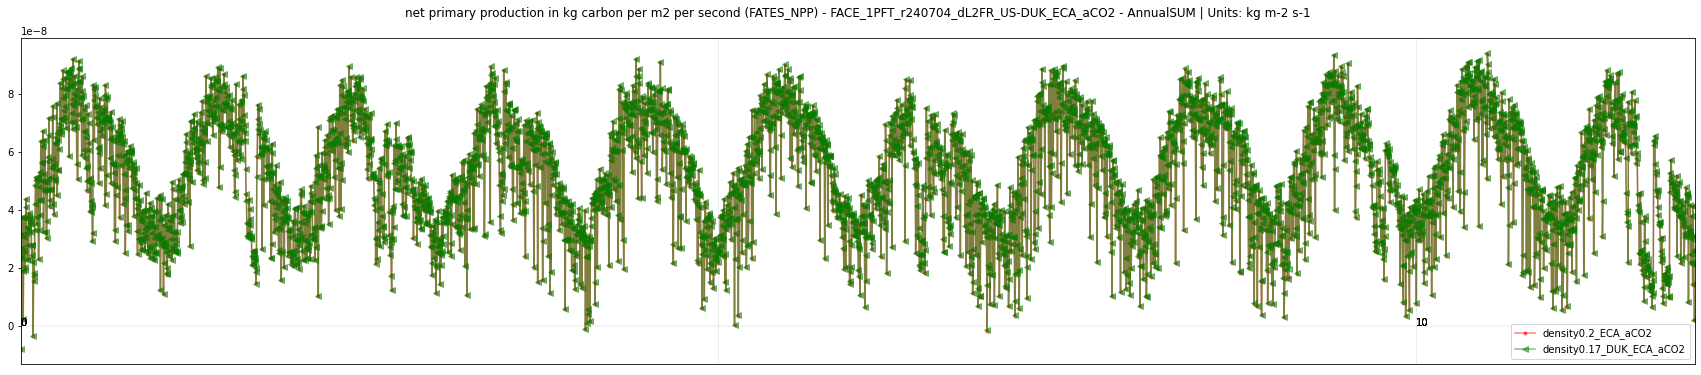

In [104]:
vars = (#"FATES_GPP",
        "FATES_NPP",
        #"FATES_AUTORESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

soil mineral N
soil mineral N
soil mineral N
soil mineral N


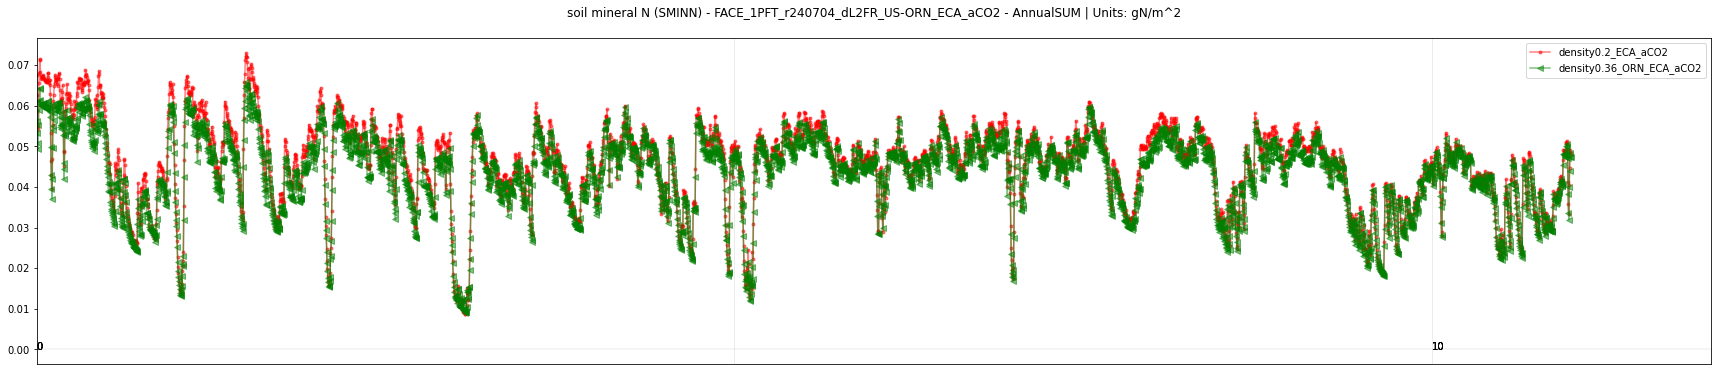

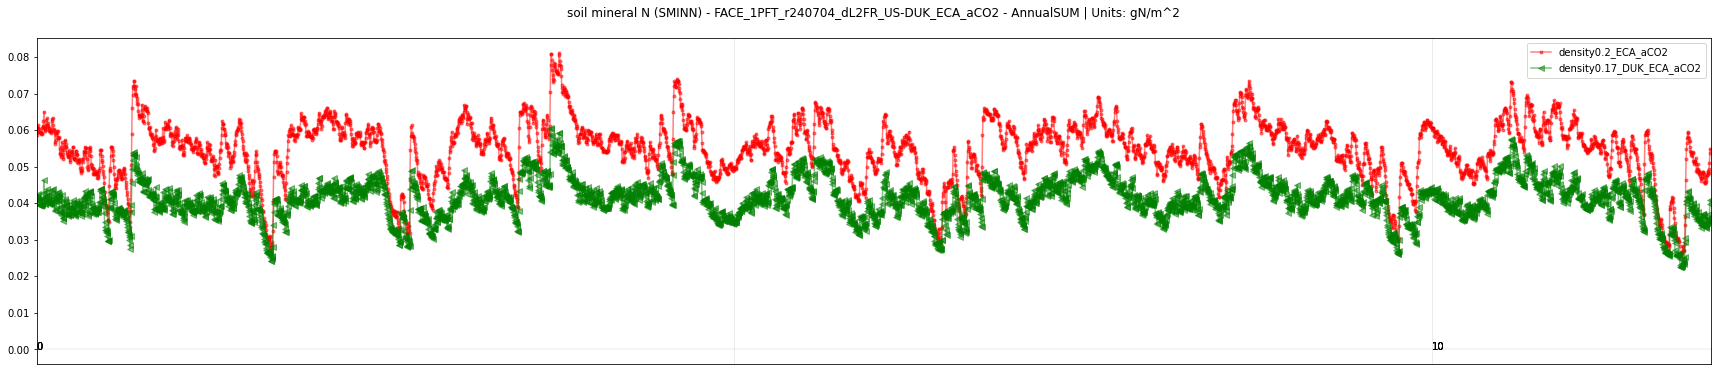

In [105]:
vars = (#"FATES_GPP",
        "SMINN",
        #"FATES_AUTORESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

gross rate of N mineralization
gross rate of N mineralization
gross rate of N mineralization
gross rate of N mineralization


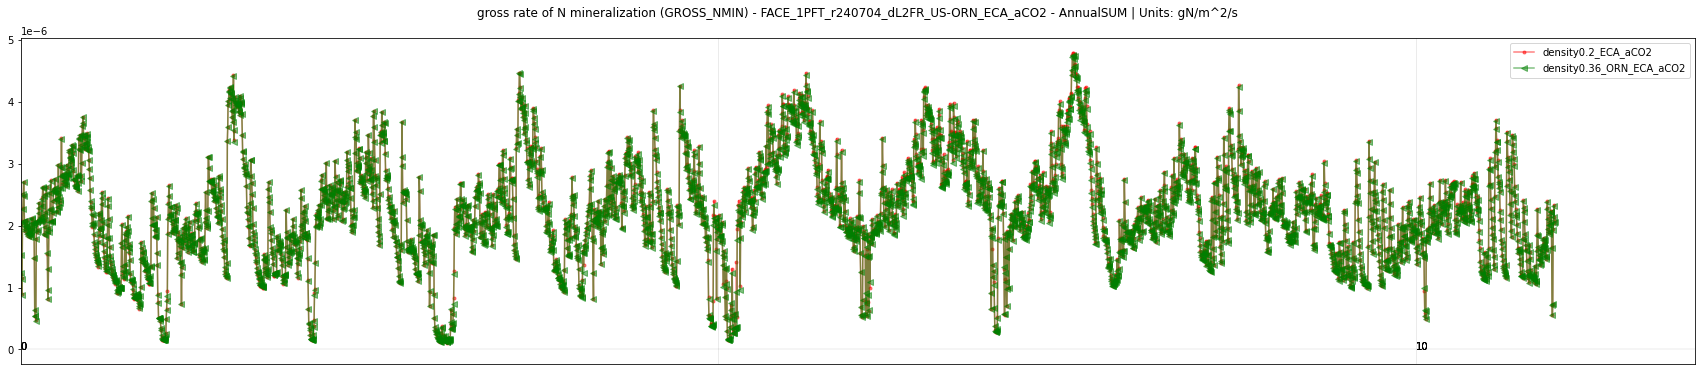

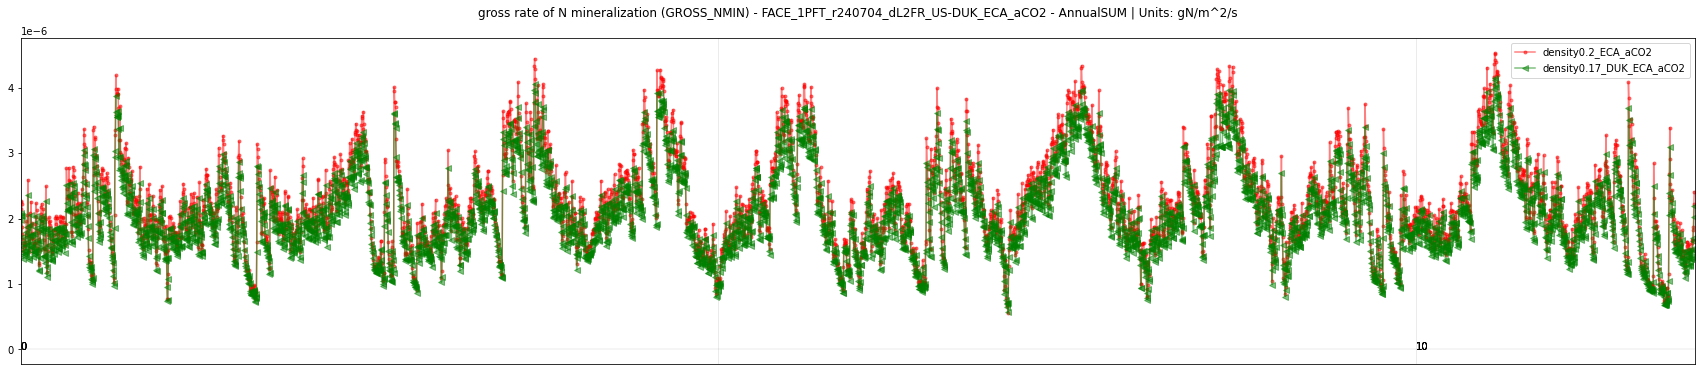

In [106]:
vars = (#"FATES_GPP",
        "GROSS_NMIN",
        #"FATES_AUTORESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

net rate of N mineralization
net rate of N mineralization
net rate of N mineralization
net rate of N mineralization


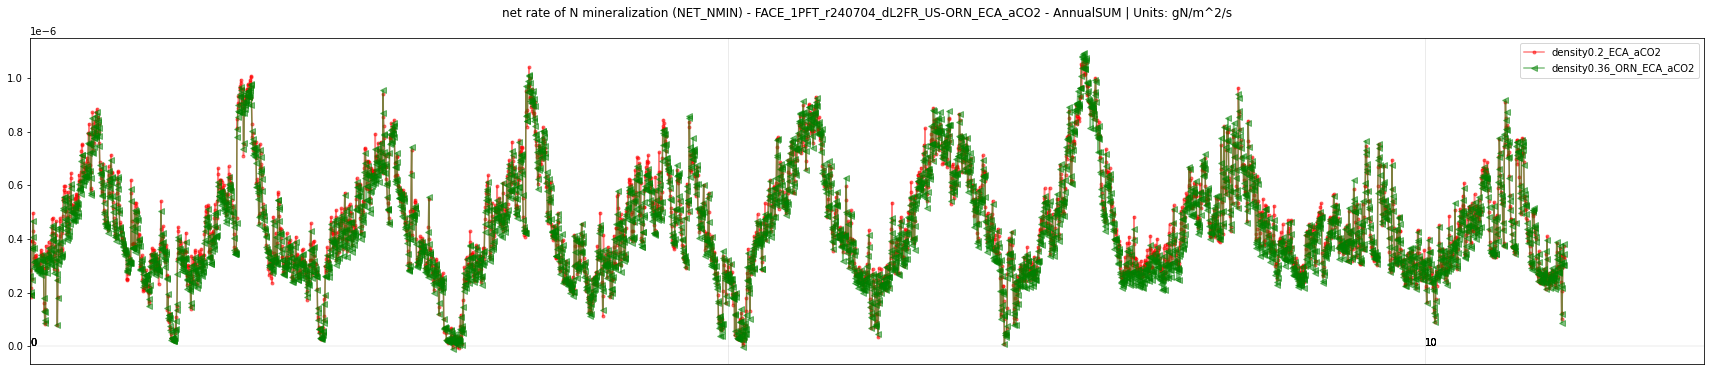

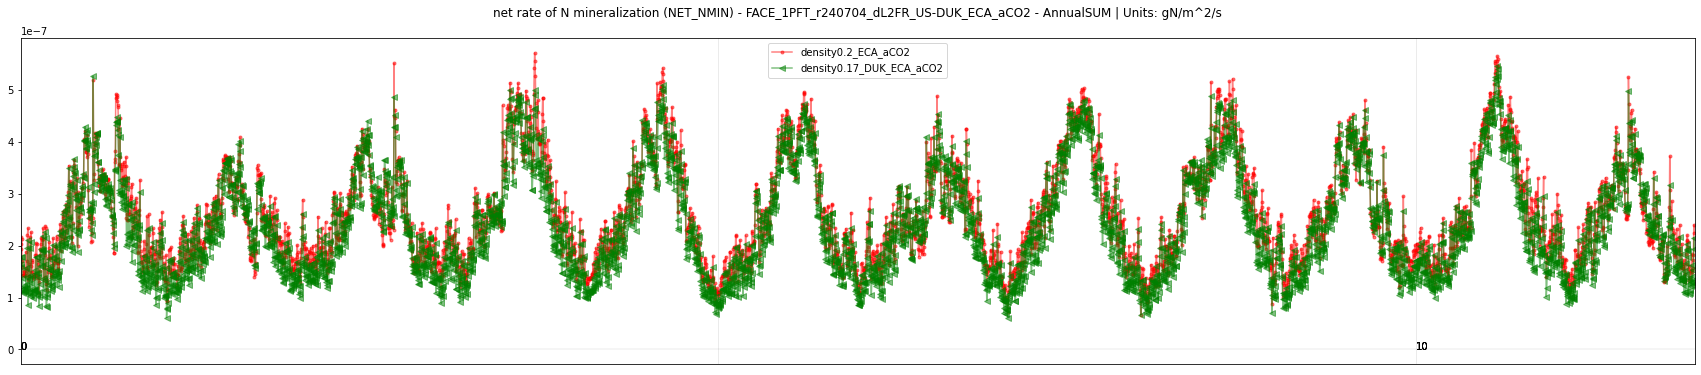

In [107]:
vars = (#"FATES_GPP",
        "NET_NMIN",
        #"FATES_AUTORESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

respiration of un-allocatable carbon gain
respiration of un-allocatable carbon gain
respiration of un-allocatable carbon gain
respiration of un-allocatable carbon gain


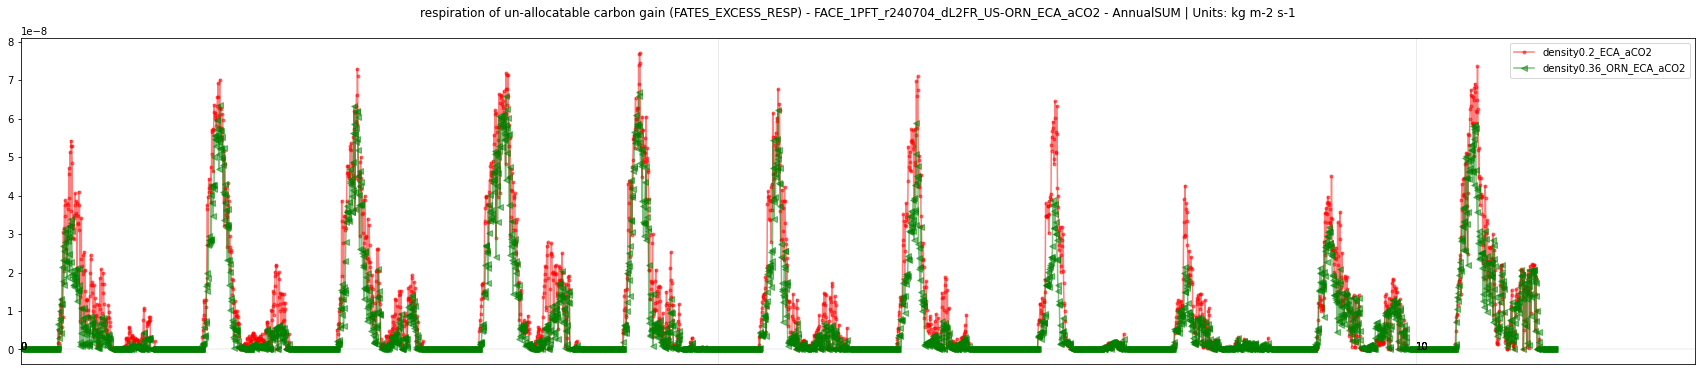

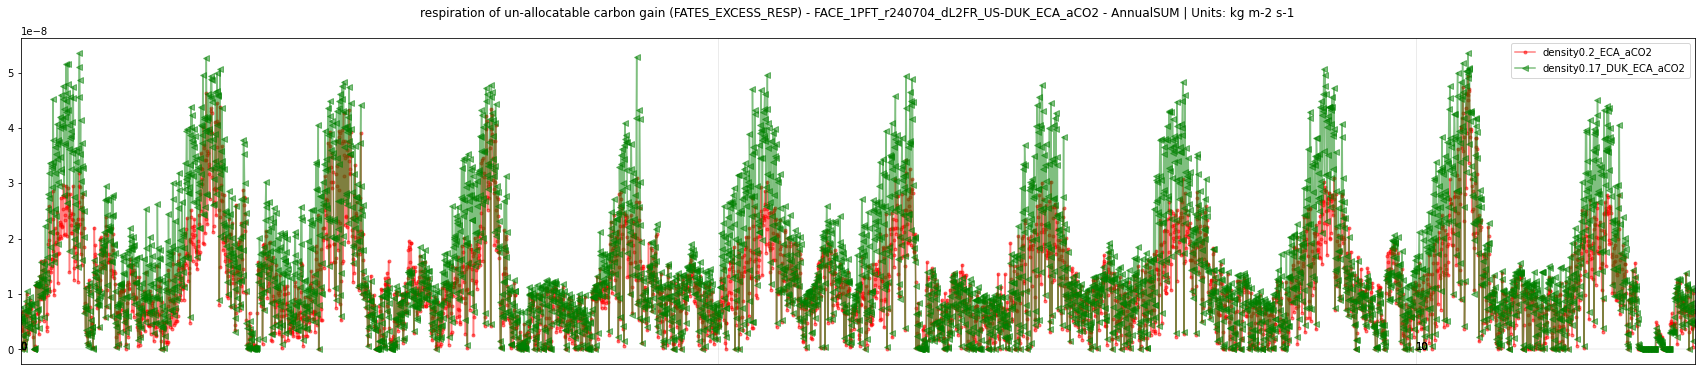

In [110]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        "FATES_EXCESS_RESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))

net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second


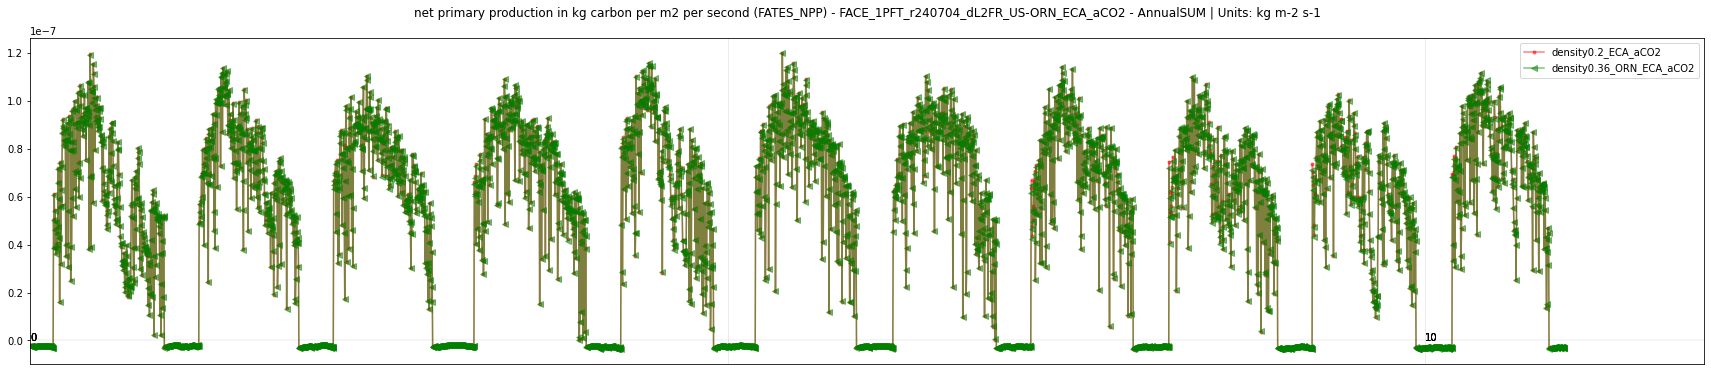

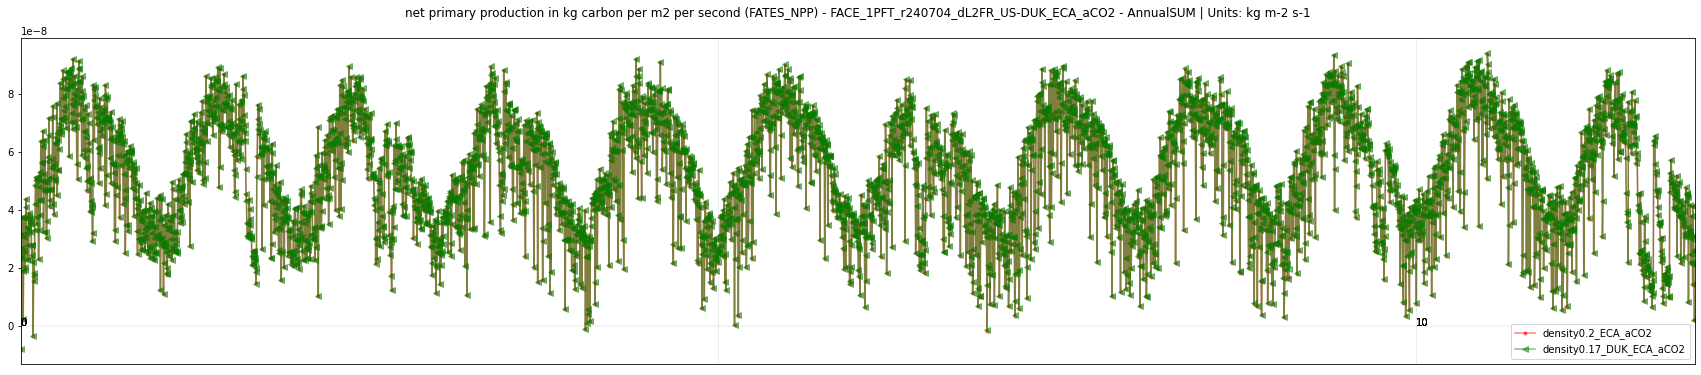

In [111]:
vars = (#"FATES_GPP",
        "FATES_NPP",
        #"FATES_EXCESS_RESP",
       )
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-ORN" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))
        #except:
        #    continue
        
li = 0 # for legend index
plt.figure(figsize=(30,6))
for idx, key in enumerate(ds.keys()):
    for sim_case in sim_cases:
        if sim_case not in key:
            continue
        for var in vars:
            if "US-DUK" in key:   
                plt.plot(ds[key][var], color =colors_list[li], marker = markers_list[li], label = tmp_legend_name(key), alpha=.5) #key.split('_')[-1])
                plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}\n")
                #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
                #plt.xlim(1850,2010)
                #plt.ylim(0,1.1)
                if idx != len(ds.keys())-1 : 
                    plt.xticks([])
                    plt.xlabel(None)
                print (ds[key][var].long_name )
                plt.legend()
                plt.xlim(0,max_r_years*multiply_factor)
                li+=1 # for legend index updating for a site
        for i in range(max_r_years):
            if i%5==0:
                plt.axvline(x = i*multiply_factor, color = 'k',lw=1, alpha=.02)
            if i%10==0:
                plt.text(i*multiply_factor,0, int(i))